In [1]:
# imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
DATA_PATH = "./data/asl_synthetic.csv"
FEATURE_COLS = [
    'flex_thumb', 'flex_index', 'flex_middle', 'flex_ring', 'flex_pinky',
    # 'accel_x', 'accel_y', 'accel_z',
    # 'gyro_x', 'gyro_y', 'gyro_z'
]

LABEL_COL = 'label'
EPOCHS = 80
BATCH_SIZE = 32

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7200, 12)


,flex_thumb,flex_index,flex_middle,flex_ring,flex_pinky,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,label
0,407,540,538,163,111,0.6039,6.8063,6.3015,0.0491,-0.0028,0.0290,P
1,214,161,167,195,136,0.7070,9.7917,0.4419,0.0107,0.0300,-0.0937,M
2,242,537,522,142,126,-0.0659,9.5484,0.6036,-0.0000,-0.0255,-0.0018,U
3,319,572,152,182,122,5.0330,7.4905,1.6872,0.0102,0.0219,0.0260,G
4,174,191,193,190,151,0.5416,9.1707,1.2603,-0.1371,0.1076,-0.0144,M


In [4]:
X = df[FEATURE_COLS].values
y_raw = df[LABEL_COL].values

encoder = LabelEncoder()
y_int = encoder.fit_transform(y_raw)
y_onehot = tf.keras.utils.to_categorical(y_int)

NUM_CLASSES = len(encoder.classes_)
print('NUM_CLASSES:', NUM_CLASSES)
print('Classes:', encoder.classes_)
print('y_onehot shape:', y_onehot.shape)

NUM_CLASSES: 36
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
y_onehot shape: (7200, 36)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42, stratify=y_int)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = keras.Sequential([
    layers.Input(shape=(5,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 36)             │         2,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,364 (44.39 KB)

 Trainable params: 11,364 (44.39 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2949 - loss: 2.4987 - val_accuracy: 0.6250 - val_loss: 1.2335
Epoch 2/80
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5714 - loss: 1.1393 - val_accuracy: 0.7222 - val_loss: 0.7270
Epoch 3/80
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6368 - loss: 0.8621 - val_accuracy: 0.7378 - val_loss: 0.6066
Epoch 4/80
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6607 - loss: 0.7580 - val_accuracy: 0.7344 - val_loss: 0.5472
Epoch 5/80
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6773 - loss: 0.6894 - val_accuracy: 0.7413 - val_loss: 0.5203
Epoch 6/80
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6933 - loss: 0.6389 - val_accuracy: 0.7569 - val_loss: 0.4908
Epoch 7/80
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6964 - loss: 0.6118 - val_accuracy: 0.7726 - val_loss: 0.4682
Epoch 8/80
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7133 - loss: 0.5757 - val_accuracy: 0.

# Evaluation

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'Test loss:     {test_loss:.4f}')

Test accuracy: 0.7778 (77.8%)
Test loss:     0.3863


In [14]:
y_pred_probs = model.predict(X_test)
y_pred_int   = np.argmax(y_pred_probs, axis=1)
y_true_int   = np.argmax(y_test, axis=1)

print(classification_report(y_true_int, y_pred_int, target_names=encoder.classes_))

 1/45 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.64      0.62      0.63        40
           1       0.51      0.93      0.66        40
           2       0.35      0.15      0.21        40
           3       1.00      1.00      1.00        40
           4       0.81      0.75      0.78        40
           5       1.00      1.00      1.00        40
           6       1.00      1.00      1.00        40
           7       1.00      1.00      1.00        40
           8       1.00      1.00      1.00        40
           9       1.00      1.00      1.00        40
           A       0.89      0.97      0.93        40
           B       0.77      0.82      0.80        40
           C       0.87      0.97      0.92        40
           D       1.00      1.00      1.00        40
           E       0.98      1.00      0.99        40
           F       1.00      1.00      1.00        40
           G       0.49      1.00      0.

c:\Users\gael8\cpe_design_1\helping-hand\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gael8\cpe_design_1\helping-hand\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gael8\cpe_design_1\helping-hand\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

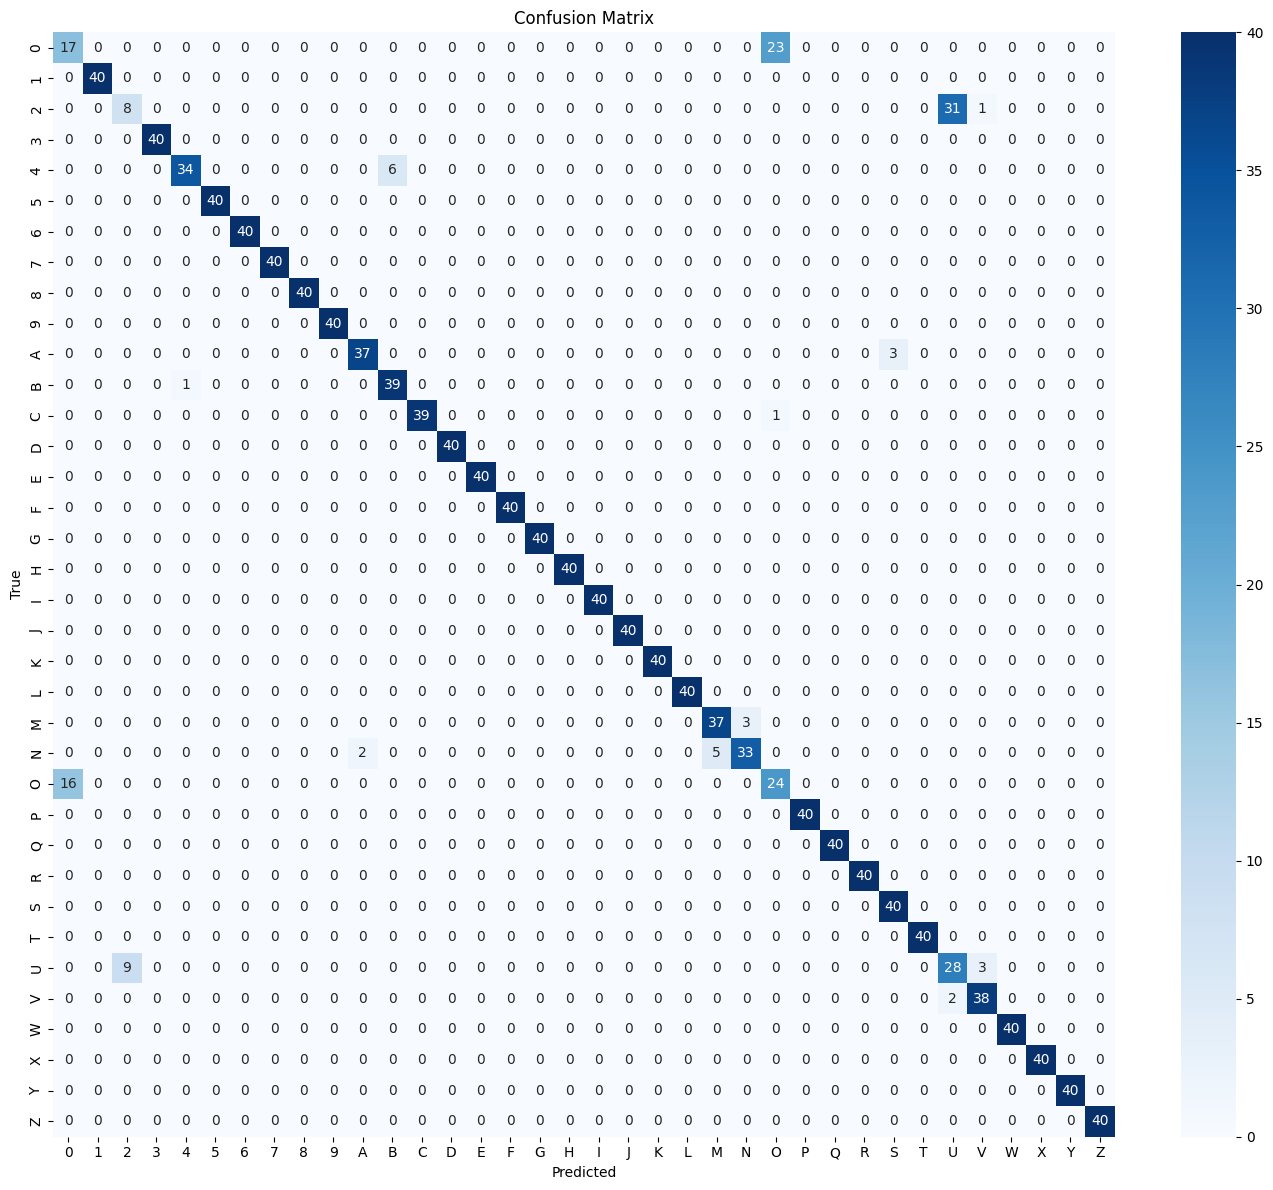

In [40]:
cm = confusion_matrix(y_true_int, y_pred_int)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
model.save('./models/asl_model.keras')
print('keras model saved')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('./models/asl_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f'tflite model saved — size: {len(tflite_model) / 1024:.1f} KB')

scaler_params = {
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'feature_cols': FEATURE_COLS,
    'classes': encoder.classes_.tolist()
}
with open('./models/scaler_params.json', 'w') as f:
    json.dump(scaler_params, f, indent=2)

print('scaler params saved')

keras model saved
INFO:tensorflow:Assets written to: C:\Users\gael8\AppData\Local\Temp\tmpw602uczq\assets


INFO:tensorflow:Assets written to: C:\Users\gael8\AppData\Local\Temp\tmpw602uczq\assets


Saved artifact at 'C:\Users\gael8\AppData\Local\Temp\tmpw602uczq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 36), dtype=tf.float32, name=None)
Captures:
  1599980125072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599980126032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599980125648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599980123536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599981864144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599981865104: TensorSpec(shape=(), dtype=tf.resource, name=None)
tflite model saved — size: 17.1 KB
scaler params saved
